In [21]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

In [22]:
import warnings
warnings.filterwarnings("ignore")

In [23]:
# day = 'Monday'
# day = 'Tuesday'
# day = 'Wednesday'
# day = 'Thursday'
day = 'Friday'

processed_filepath = './datasets/processed/'
data = pd.read_csv(processed_filepath + f'{day}.csv')
df = data.copy()

In [24]:
df.head()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,3268,112740690,32,16,6448,1152,403,0,201.5,204.724205,...,32,3.594286e+02,1.199802e+01,380,343,16100000.0,4.988048e+05,16400000,15400000,0
1,389,112740560,32,16,6448,5056,403,0,201.5,204.724205,...,32,3.202857e+02,1.574499e+01,330,285,16100000.0,4.987937e+05,16400000,15400000,0
2,0,113757377,545,0,0,0,0,0,0.0,0.000000,...,0,9.361829e+06,7.324646e+06,18900000,19,12200000.0,6.935824e+06,20800000,5504997,0
3,5355,100126,22,0,616,0,28,28,28.0,0.000000,...,32,0.000000e+00,0.000000e+00,0,0,0.0,0.000000e+00,0,0,0
4,0,54760,4,0,0,0,0,0,0.0,0.000000,...,0,0.000000e+00,0.000000e+00,0,0,0.0,0.000000e+00,0,0,0


In [25]:
print("Unikalne wartości w kolumnie 'Label':")
unique_labels = df['Label'].unique()
label_counts = df['Label'].value_counts()

print(unique_labels)
print(label_counts)

Unikalne wartości w kolumnie 'Label':
[0 1]
Label
0    413933
1    288785
Name: count, dtype: int64


In [26]:
X = df.drop('Label', axis=1).values
y = df['Label'].values

Epoch 1/10
17568/17568 ━━━━━━━━━━━━━━━━━━━━ 9s 515us/step - Precision: 0.6221 - Recall: 0.9992 - accuracy: 0.7418 - loss: 0.6268 - val_Precision: 0.7440 - val_Recall: 1.0000 - val_accuracy: 0.8586 - val_loss: 2.2507
Epoch 2/10
17568/17568 ━━━━━━━━━━━━━━━━━━━━ 9s 496us/step - Precision: 0.7372 - Recall: 0.9999 - accuracy: 0.8532 - loss: 0.3711 - val_Precision: 0.7813 - val_Recall: 0.9999 - val_accuracy: 0.8849 - val_loss: 0.9348
Epoch 3/10
17568/17568 ━━━━━━━━━━━━━━━━━━━━ 9s 514us/step - Precision: 0.7339 - Recall: 0.9999 - accuracy: 0.8507 - loss: 0.5651 - val_Precision: 0.7146 - val_Recall: 1.0000 - val_accuracy: 0.8358 - val_loss: 5.0796
Epoch 4/10
17568/17568 ━━━━━━━━━━━━━━━━━━━━ 10s 547us/step - Precision: 0.7541 - Recall: 0.9999 - accuracy: 0.8658 - loss: 0.4751 - val_Precision: 0.8427 - val_Recall: 0.9998 - val_accuracy: 0.9232 - val_loss: 0.9421
Epoch 5/10
17568/17568 ━━━━━━━━━━━━━━━━━━━━ 10s 546us/step - Precision: 0.7132 - Recall: 0.9998 - accuracy: 0.8347 - loss: 1.2838 - val

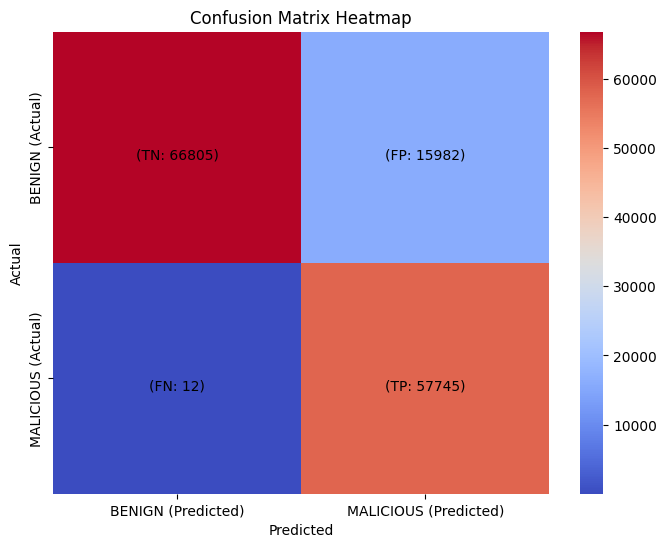

Classification Report:
              precision    recall  f1-score   support

      BENIGN       1.00      0.81      0.89     82787
   MALICIOUS       0.78      1.00      0.88     57757

    accuracy                           0.89    140544
   macro avg       0.89      0.90      0.89    140544
weighted avg       0.91      0.89      0.89    140544



In [27]:
scaler = StandardScaler()
X_normalized = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_normalized, y, test_size=0.2, random_state=42, stratify=y)
import warnings
warnings.filterwarnings("ignore")

model = Sequential([
    Input((X_train.shape[1],)),
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    # Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy', 'Precision', 'Recall'])

from sklearn.utils.class_weight import compute_class_weight
import numpy as np


# total_samples = len(y_train)
# class_0_weight = total_samples / (2 * np.sum(y_train == 0))
# class_1_weight = total_samples / (2 * np.sum(y_train == 1))
# print(class_0_weight, class_1_weight)

class_weights = {0: 0.1, 1: 300.0}
# class_weights = dict(enumerate(compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)))

start_time = time.time()
history = model.fit(X_train, y_train, epochs=10, batch_size=32, validation_data=(X_test, y_test), class_weight=class_weights)
# model.fit(X_train, y_train, epochs=20, batch_size=32, validation_data=(X_test, y_test))

y_pred_probs = model.predict(X_test)
y_pred_classes = (y_pred_probs >= 0.5).astype(int)

end_time = time.time() 
print("Work time: ", end_time - start_time, "s")

cm = confusion_matrix(y_test, y_pred_classes)
print("Confusion Matrix:")
print(cm)

# Wizualizacja macierzy konfuzji
plt.figure(figsize=(8, 6))
ax = sns.heatmap(cm, annot=False, fmt='d', cmap='coolwarm', 
                 xticklabels=['BENIGN (Predicted)', 'MALICIOUS (Predicted)'], 
                 yticklabels=['BENIGN (Actual)', 'MALICIOUS (Actual)'])

labels = [[f'TN: {cm[0][0]}', f'FP: {cm[0][1]}'], 
          [f'FN: {cm[1][0]}', f'TP: {cm[1][1]}']]
for i in range(2):
    for j in range(2):
        ax.text(j + 0.5, i + 0.5, f'\n({labels[i][j]})', 
                color='Black', ha='center', va='center', fontsize=10)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix Heatmap')
plt.show()

print("Classification Report:")
print(classification_report(y_test, y_pred_classes, target_names=['BENIGN', 'MALICIOUS']))

In [28]:
import numpy as np
import os

TN, FP = cm[0]
FN, TP = cm[1]

accuracy = (TP + TN) / (TP + TN + FP + FN)
precision = TP / (TP + FP) if (TP + FP) > 0 else 0
recall = TP / (TP + FN) if (TP + FN) > 0 else 0
f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

In [29]:
results_dir = './results/MLP/'
os.makedirs(results_dir, exist_ok=True)
results_filepath = results_dir + f'MLP_{day}_model_results.txt'

with open(results_filepath, 'w') as f:
    f.write("==========================================================================================\n")
    f.write("===\n")
    f.write(f"{results_filepath}\n")
    f.write("===\n")
    f.write(f"Czas uczenia: {end_time - start_time:.2f} s\n")
    f.write(f"Macierz konfuzji:\n")
    f.write(f"[[ True Negatives (TN): {cm[0][0]}   False Positives (FP): {cm[0][1]} ]\n")
    f.write(f" [ False Negatives (FN): {cm[1][0]}   True Positives (TP): {cm[1][1]} ]]\n\n")
    f.write(f"Accuracy: {accuracy:.2%}\n")
    f.write(f"Precision (dla klasy ATTACK): {precision:.2%}\n")
    f.write(f"Recall (dla klasy ATTACK): {recall:.2%}\n")
    f.write(f"F1-score: {f1_score:.2%}\n")
    f.write("==========================================================================================\n")

Note
=== Wyniki modelu ===
Macierz konfuzji:
[[ True Negatives (TN): 88175 False Positives (FP): 3108 ]
[ False Negatives (FN): 4 True Positives (TP): 439 ]]

Accuracy: 96.61%
Precision (dla klasy ATTACK): 12.38%
Recall (dla klasy ATTACK): 99.10%
F1-score: 22.01%

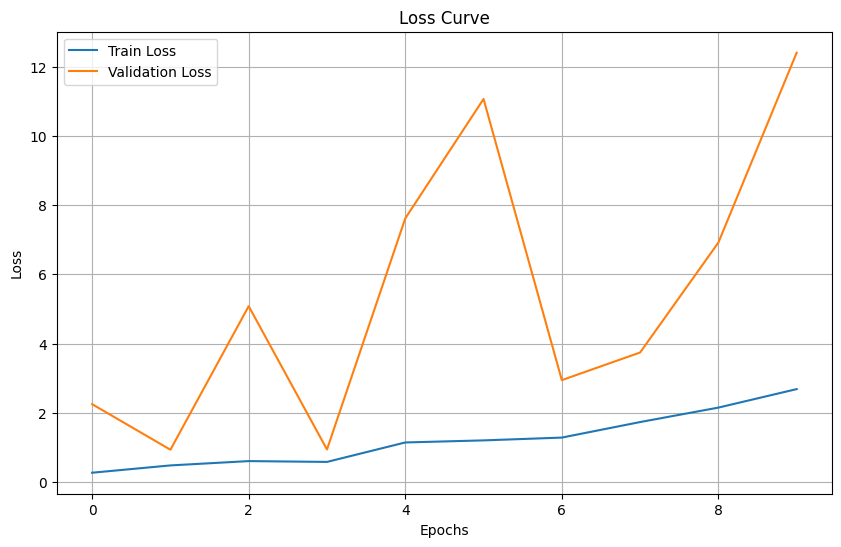

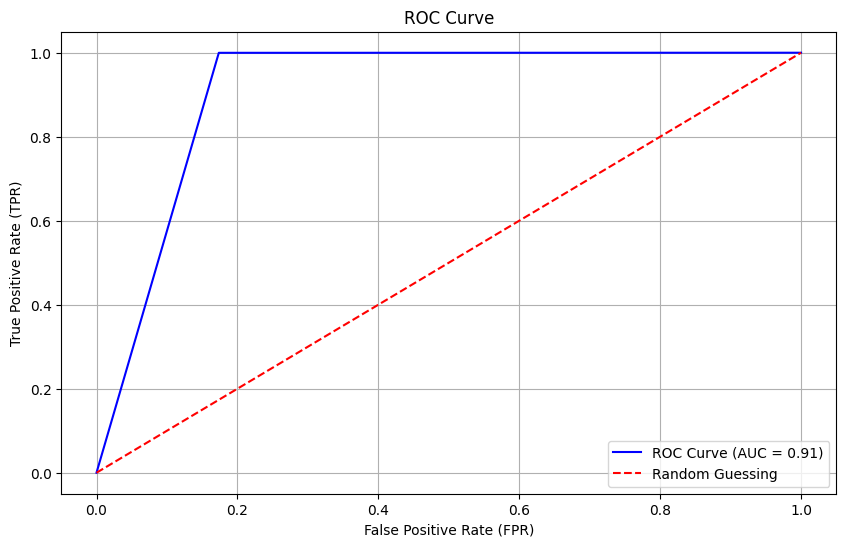

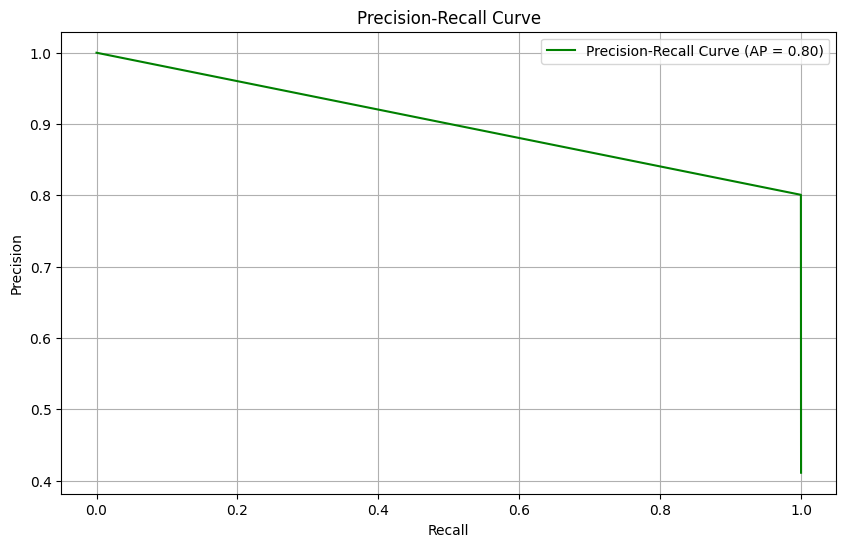

In [30]:
def make_loss_plot():
    plt.figure(figsize=(10, 6))
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Loss Curve')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid()
    plt.show()

def make_roc_plot():
    from sklearn.metrics import roc_curve, auc

    fpr, tpr, thresholds = roc_curve(y_test, y_pred_probs)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(10, 6))
    plt.plot(fpr, tpr, color='blue', label=f'ROC Curve (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Random Guessing')
    plt.title('ROC Curve')
    plt.xlabel('False Positive Rate (FPR)')
    plt.ylabel('True Positive Rate (TPR)')
    plt.legend()
    plt.grid()
    plt.show()

def make_precission_recall_plot():
    from sklearn.metrics import precision_recall_curve, average_precision_score

    precision, recall, thresholds = precision_recall_curve(y_test, y_pred_probs)
    average_precision = average_precision_score(y_test, y_pred_probs)

    plt.figure(figsize=(10, 6))
    plt.plot(recall, precision, color='green', label=f'Precision-Recall Curve (AP = {average_precision:.2f})')
    plt.title('Precision-Recall Curve')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.legend()
    plt.grid()
    plt.show()


make_loss_plot()
make_roc_plot()
make_precission_recall_plot()